# 2.3 - Modeling - Testing

aaaaaaaaaaaaaaa

aaaaaaaaaaaaaaa
aaaaaaaaaaaaaaa

aaaaaaaaaaaaaaa
aaaaaaaaaaaaaaa

## Importing Libs

In [1]:
# Importing Libs
    
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid", rc={'figure.figsize':(10,6)})

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score, precision_score, recall_score, precision_recall_curve, ConfusionMatrixDisplay


from xgboost import XGBClassifier

import joblib
import warnings

## Importing Dataset and Feature Engeneering

In this step:
- The dataset was imported
- The values created in section **1 - EDA.ipynb**, `balanceOrigDiff` and `balanceDestDiff` were used
- Values that would not be relevant in the forecast were removed

In [2]:
FRAUD_PATH = "datasets/AIML Dataset.csv"

df = pd.read_csv(FRAUD_PATH)

categorical_features = ['type', 'nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud']
numerical_features = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

df['balanceOrigDiff'] = df['newbalanceOrig'] - df['oldbalanceOrg']
df['balanceDestDiff'] = df['newbalanceDest'] - df['oldbalanceDest']

features_model = numerical_features + ['balanceOrigDiff', 'balanceDestDiff', 'isFraud']
df_model = df[features_model]

df_model.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balanceOrigDiff,balanceDestDiff,isFraud
0,1,9839.64,170136.0,160296.36,0.0,0.0,-9839.64,0.0,0
1,1,1864.28,21249.0,19384.72,0.0,0.0,-1864.28,0.0,0
2,1,181.00,181.0,0.00,0.0,0.0,-181.00,0.0,1
3,1,181.00,181.0,0.00,21182.0,0.0,-181.00,-21182.0,1
4,1,11668.14,41554.0,29885.86,0.0,0.0,-11668.14,0.0,0


## Train Test Split

The data was divided as follows:
- The class of interest (`isFraud`) was separated as **y** and the others as **X**
- The division was made in a 70-30 ratio due to the high volume of data
- The `stratify` hyperparameter was used in order to maintain the proportion of positive and negative classes for both the test set and the training set
- Since there are no categorical values, it was only necessary to make the `StandardScaler`

In [3]:
y = df_model["isFraud"]
X = df_model.drop("isFraud", axis = 1)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify=y, random_state = 42)

In [5]:
scaler =  StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

`StratifiedKFold` is used to divide the data into K parts (folds) to perform cross-validation, maintaining the proportion of classes in each fold.
In other words, in each Cross-Validation it is guaranteed that each fold has representation of the classes.

In [8]:
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Testing

In [9]:
MODEL_EVALUATION_METRICS = [
    "accuracy",
    "balanced_accuracy",
    "f1",
    "precision",
    "recall",
    "roc_auc",
    "average_precision",
    "neg_brier_score",
    "f1_weighted",
]

In [10]:
filename = 'best_xgb_model.joblib'
xgbclf = joblib.load(filename)

In [11]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    
    scores = cross_validate(estimator = xgbclf, X = X_train, y = y_train, cv=stratified_kfold, scoring=MODEL_EVALUATION_METRICS)

In [332]:
def score_to_df(score, sum_time):
    """


    """

    df = pd.DataFrame(score)
    

    if sum_time:
        df['total_time'] = df['fit_time'] + df['score_time']
        df = df.drop(columns=['fit_time', 'score_time'])

    df = df.T

    mean_series = df.mean(axis=1)

    return(df, mean_series)
df_test, mean_series = score_to_df(score = scores, sum_time = True)
df_test

,0,1,2,3,4
test_accuracy,0.999689,0.999679,0.999695,0.999696,0.999656
test_balanced_accuracy,0.910395,0.907784,0.911700,0.908227,0.899001
test_f1,0.872055,0.867715,0.874423,0.873895,0.857009
test_precision,0.930049,0.926877,0.932087,0.939940,0.925328
test_recall,0.820870,0.815652,0.823478,0.816522,0.798085
test_roc_auc,0.999312,0.999355,0.998619,0.999622,0.999528
test_average_precision,0.942226,0.937469,0.938549,0.938762,0.931821
test_neg_brier_score,-0.000241,-0.000254,-0.000241,-0.000248,-0.000271
test_f1_weighted,0.999679,0.999669,0.999685,0.999685,0.999644
total_time,61.673532,66.198534,64.832847,52.321478,53.958039


In [336]:
mean_series

test_accuracy              0.999683
test_balanced_accuracy     0.907422
test_f1                    0.869020
test_precision             0.930856
test_recall                0.814921
test_roc_auc               0.999287
test_average_precision     0.937765
test_neg_brier_score      -0.000251
test_f1_weighted           0.999672
total_time                59.796886
dtype: float64

In [20]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")

    y_proba = cross_val_predict(estimator = xgbclf, X = X_train, y = y_train, cv=stratified_kfold, method="predict_proba")

In [28]:
precisions, recalls, thresholds = precision_recall_curve(y_train, y_proba[:, 1])

print("Precision: {}".format(precisions))
print("Recall: {}".format(recalls))
print("Threshold: {}".format(thresholds))

Precision: [0.0012908 0.0012908 0.0012908 ... 1.        1.        1.       ]
Recall: [1.         1.         1.         ... 0.00417464 0.00260915 0.        ]
Threshold: [2.2565717e-11 2.3723754e-11 2.5062152e-11 ... 9.9999964e-01 9.9999976e-01
 9.9999988e-01]


In [348]:
def precision_and_recall_scores_plot(threshold, precision, recall, mean_prec, mean_rec):
    """

    Obs: if you have used precision_recall_curve, you'll need to set the values of recall and precision with [:-1]. ex: precisions[:-1]

    """

    # 4. Encontrar o ponto mais próximo (menor distância euclidiana)
    distances = np.sqrt((precision - mean_prec)**2 + (recall - mean_rec)**2)
    best_threshold_idx = np.argmin(distances)
    best_threshold = threshold[best_threshold_idx]
    
    # 5. Plotar o gráfico com marcação do threshold
    plt.figure(figsize=(10, 6))
    plt.plot(threshold, precision, label="Precision", color="blue")
    plt.plot(threshold, recall, label="Recall", color="green")
    
    # Linha vertical no melhor threshold
    plt.axvline(best_threshold, color="red", linestyle="--", label=f"Threshold ≈ {best_threshold:.3f}")
    
    # Ponto destacado no gráfico
    plt.scatter(threshold[best_threshold_idx], precision[best_threshold_idx], color="blue", marker='o')
    plt.scatter(threshold[best_threshold_idx], recall[best_threshold_idx], color="green", marker='o')
    
    plt.title("Precision and Recall vs Threshold")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()

    return(None)

C:\Users\erhon\anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


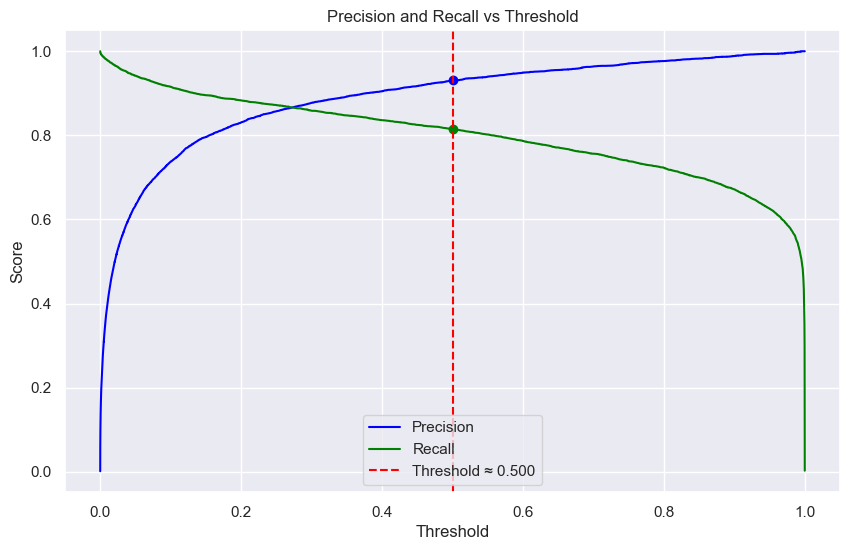

In [350]:
precision_and_recall_scores_plot(threshold = thresholds, 
                                 precision = precisions[:-1], 
                                 recall = recalls[:-1], 
                                 mean_prec = mean_series["test_precision"], 
                                 mean_rec = mean_series["test_recall"])

In [38]:
# Previsão
y_pred = xgbclf.predict(X_test)

# Avaliação
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998   1906322
           1     0.9250    0.8064    0.8617      2464

    accuracy                         0.9997   1908786
   macro avg     0.9624    0.9032    0.9307   1908786
weighted avg     0.9997    0.9997    0.9997   1908786



In [454]:
def confusion_matrix_disp(true_y, pred_y,titles, norm = None):
    """

    """
    fig, ax = plt.subplots(figsize=(6, 6))

    ConfusionMatrixDisplay.from_predictions(y_true = true_y,
                                            y_pred = pred_y,
                                            ax = ax,
                                            normalize = norm, 
                                            cmap = "RdBu",
                                            im_kw = {"alpha": 0.75},
                                            text_kw = {"size": "large", "color": "white", "fontweight": "bold"},
                                           )

    fig.suptitle("Confusion Matrix for the Best Model")
    ax.set_title(titles)
    
    plt.grid(False)
    plt.show()


    return(None)

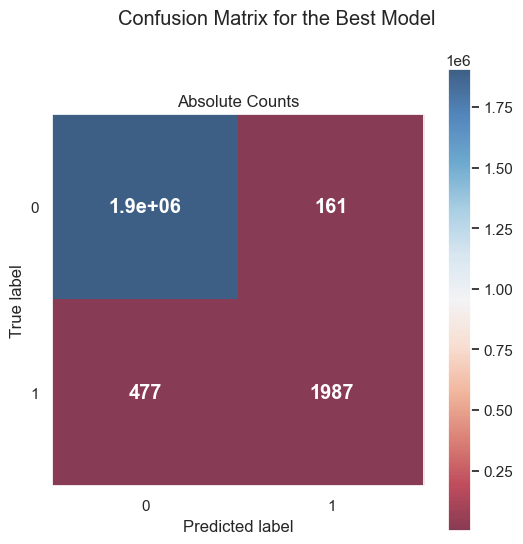

In [456]:
confusion_matrix_disp(true_y = y_test, pred_y = y_pred, titles = "Absolute Counts", norm = None)

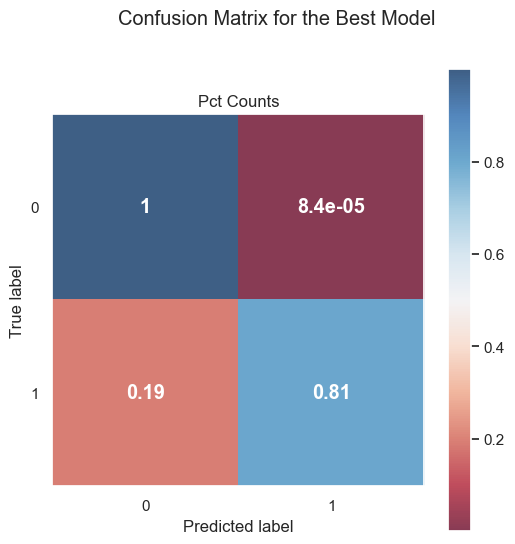

In [457]:
confusion_matrix_disp(true_y = y_test, pred_y = y_pred, titles = "Pct Counts", norm = "true")

In [267]:
def recall_for_precision(y_train, y_prob, threshold, n_prec, precision):
    """



    """

    idx_for_XX_precision = (precision >= n_prec).argmax()
    threshold_for_XX_precision = threshold[idx_for_XX_precision]

    print(f"The threshold for the precision {(n_prec*100):.3f} is: {threshold_for_XX_precision:.3f}")

    y_train_pred_XX = (y_prob >= threshold_for_XX_precision)
    nearest_precision = precision_score(y_train, y_train_pred_XX[:,1])
    
    print(f"The nearest precision from {(n_prec*100):.3f} is: {(nearest_precision*100):.3f}%")
    
    recall_at_XX_precision = recall_score(y_train, y_train_pred_XX[:,1])
    
    print(f"The threshold for the precision {(n_prec*100):.3f} is: {(recall_at_XX_precision*100):.3f}%")

    return(None)
    
recall_for_precision(y_train = y_train, 
                     y_prob = y_proba, 
                     threshold = thresholds, 
                     n_prec = 0.885, 
                     precision = precisions)    

The threshold for the precision 88.500 is: 0.324
The nearest precision from 88.500 is: 88.508%
The threshold for the precision 88.500 is: 85.337%


In [265]:
def precision_for_recall(y_train, y_prob, threshold, n_rec, recall):
    """



    """

    idx_for_XX_recall = (recall >= n_rec).argmin()
    threshold_for_XX_recall = threshold[idx_for_XX_recall]

    print(f"The threshold for the recall {(n_rec*100):.3f} is: {threshold_for_XX_recall:.3f}")

    y_train_pred_XX = (y_prob >= threshold_for_XX_recall)
    nearest_recall = recall_score(y_train, y_train_pred_XX[:,1])
    
    print(f"The nearest recall from {(n_rec*100):.3f} is: {(nearest_recall*100):.3f}%")
    
    precision_at_XX_recall = precision_score(y_train, y_train_pred_XX[:,1])
    
    print(f"The threshold for the recall {(n_rec*100):.3f} is: {(precision_at_XX_recall*100):.3f}%")

    return(None)

precision_for_recall(y_train = y_train, 
                     y_prob = y_proba, 
                     threshold = thresholds, 
                     n_rec = 0.85337, 
                     recall = recalls)

The threshold for the recall 85.337 is: 0.322
The nearest recall from 85.337 is: 85.337%
The threshold for the recall 85.337 is: 88.428%
